IMAGE CLASSIFICATION WITH LOGISTIC REGRESSION

In this kernel, I used grid search method in logistic regression to classify rooms as messy or clean.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
!unzip archive.zip -d fer2013

Streaming output truncated to the last 5000 lines.
  inflating: fer2013/train/sad/Training_65242339.jpg  
  inflating: fer2013/train/sad/Training_65267116.jpg  
  inflating: fer2013/train/sad/Training_65275626.jpg  
  inflating: fer2013/train/sad/Training_6529266.jpg  
  inflating: fer2013/train/sad/Training_65329617.jpg  
  inflating: fer2013/train/sad/Training_65338712.jpg  
  inflating: fer2013/train/sad/Training_65338797.jpg  
  inflating: fer2013/train/sad/Training_65387162.jpg  
  inflating: fer2013/train/sad/Training_65404494.jpg  
  inflating: fer2013/train/sad/Training_65426218.jpg  
  inflating: fer2013/train/sad/Training_65430136.jpg  
  inflating: fer2013/train/sad/Training_65437377.jpg  
  inflating: fer2013/train/sad/Training_6545735.jpg  
  inflating: fer2013/train/sad/Training_65463385.jpg  
  inflating: fer2013/train/sad/Training_65473985.jpg  
  inflating: fer2013/train/sad/Training_65502829.jpg  
  inflating: fer2013/train/sad/Training_65505359.jpg  
  inflating: fer

In [ ]:
import os

print(os.listdir("fer2013"))

['train', 'test']


In [ ]:
import os

print(os.listdir("fer2013/train"))

['fear', 'neutral', 'disgust', 'surprise', 'happy', 'sad', 'angry']


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import cv2
import os
from random import shuffle
from tqdm import tqdm
from PIL import Image
# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory
import warnings
warnings.filterwarnings('ignore')
import os
print(os.listdir("fer2013"))
print(os.listdir("fer2013/train"))
print(os.listdir("fer2013/test"))

# Any results you write to the current directory are saved as output.

['train', 'test']
['fear', 'neutral', 'disgust', 'surprise', 'happy', 'sad', 'angry']
['fear', 'neutral', 'disgust', 'surprise', 'happy', 'sad', 'angry']


In [ ]:
train_path = "fer2013/train"
test_path = "fer2013/test"

image_size = 48

An emotion


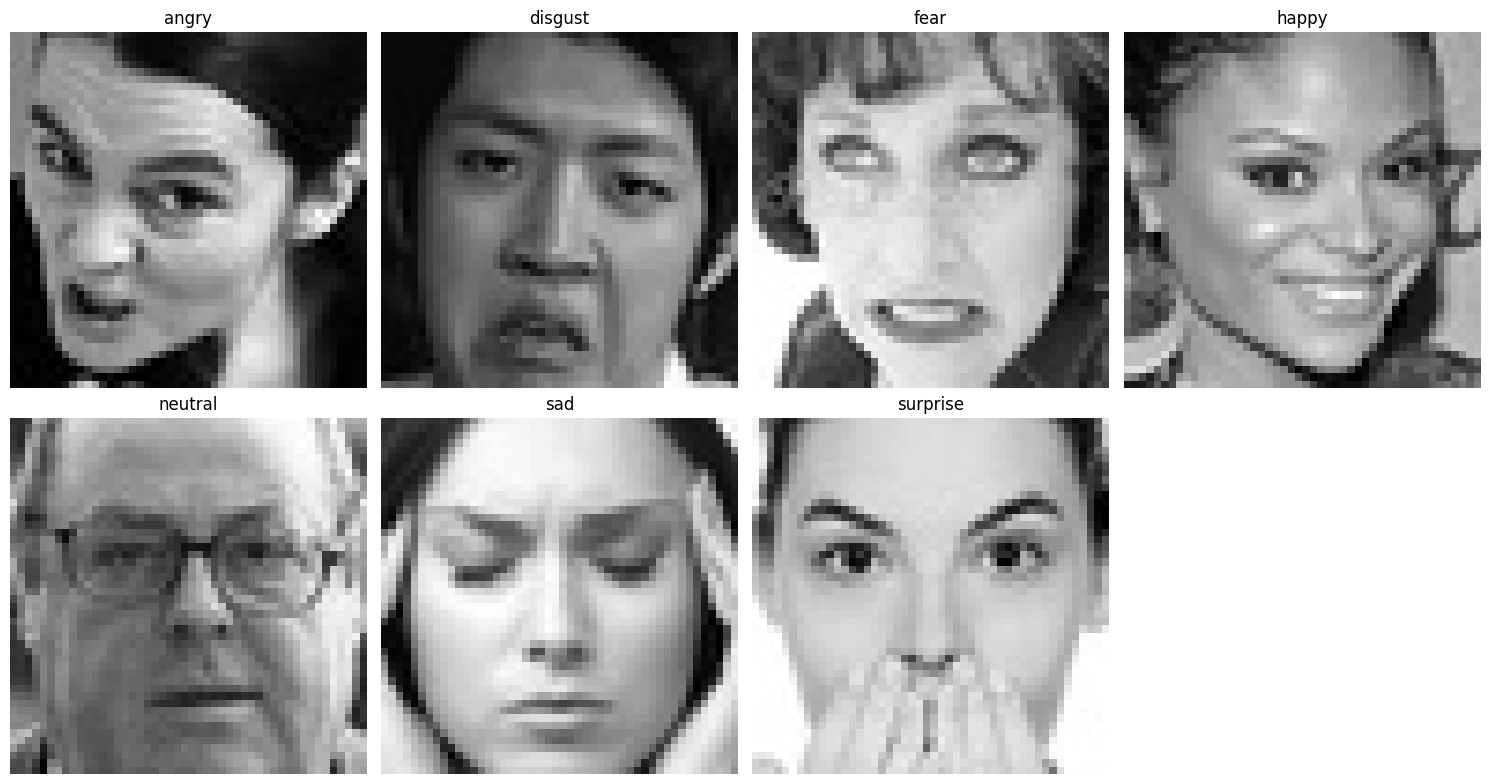

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

train_path = "fer2013/train"

classes = sorted(os.listdir(train_path))

plt.figure(figsize=(15,8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(train_path, class_name)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    img = Image.open(image_path)

    plt.subplot(2,4,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

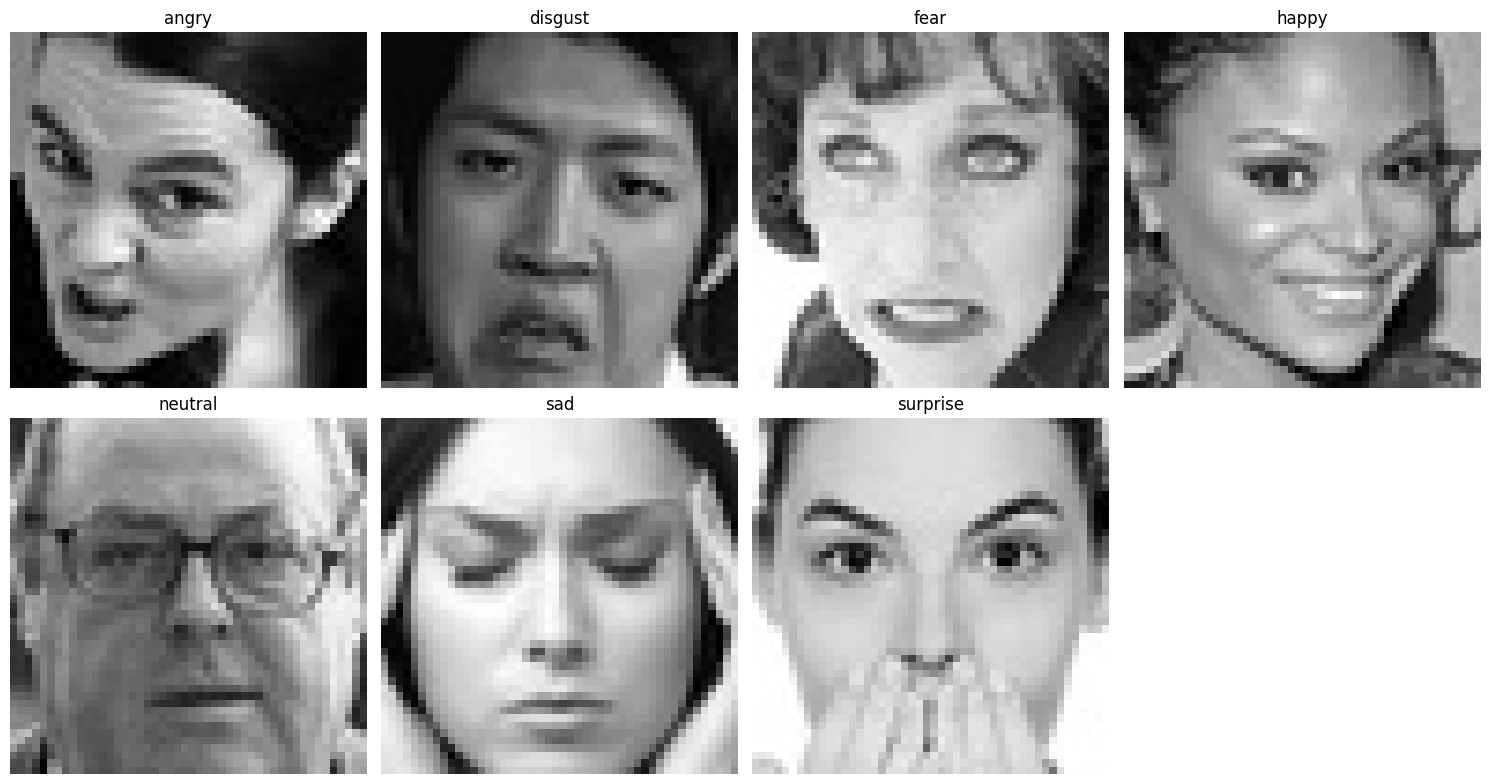

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

train_path = "fer2013/train"

classes = sorted(os.listdir(train_path))

plt.figure(figsize=(15,8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(train_path, class_name)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img, (image_size, image_size))

    plt.subplot(2,4,i+1)

    plt.imshow(img, cmap='gray')

    plt.title(class_name)

    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def load_train_data():

    X_train = []
    y_train = []

    classes = sorted(os.listdir(train_path))

    for label, class_name in enumerate(classes):

        class_path = os.path.join(train_path, class_name)

        for image_name in tqdm(os.listdir(class_path)):

            image_path = os.path.join(class_path, image_name)

            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

            img = cv2.resize(img, (image_size, image_size))

            X_train.append(img.flatten())

            y_train.append(label)

    X_train = np.asarray(X_train)
    y_train = np.asarray(y_train)

    return X_train, y_train

In [ ]:
def load_test_data():

    X_test = []
    y_test = []

    classes = sorted(os.listdir(test_path))

    for label, class_name in enumerate(classes):

        class_path = os.path.join(test_path, class_name)

        for image_name in tqdm(os.listdir(class_path)):

            image_path = os.path.join(class_path, image_name)

            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

            img = cv2.resize(img, (image_size, image_size))

            X_test.append(img.flatten())

            y_test.append(label)

    X_test = np.asarray(X_test)
    y_test = np.asarray(y_test)

    return X_test, y_test

In [ ]:
X_train, y_train = load_train_data()
X_test, y_test = load_test_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

100%|██████████| 831/831 [00:00<00:00, 14905.48it/s]

X_train: (28709, 2304)
y_train: (28709,)
X_test: (7178, 2304)
y_test: (7178,)


In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (28709, 2304)
y_train shape: (28709,)
X_test shape: (7178, 2304)
y_test shape: (7178,)


In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (28709, 2304)
X_test shape: (7178, 2304)


LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import time

def run_logistic_experiment(C_value, max_iter_value):
    print(f"\nRunning Logistic Regression: C={C_value}, max_iter={max_iter_value}")

    start_time = time.time()

    model = LogisticRegression(
        max_iter=max_iter_value,
        solver='saga',
        C=C_value,
        multi_class='multinomial',
        n_jobs=-1,
        verbose=3
    )

    model.fit(X_train, y_train)

    training_time = time.time() - start_time

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    print("Training time:", round(training_time, 2), "seconds")
    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)

    print("\nTest Classification Report:")
    print(classification_report(y_test, y_test_pred, target_names=classes))

       # =========================
    # Confusion Matrix
    # =========================
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt

    cm = confusion_matrix(y_test, y_test_pred)

    plt.figure(figsize=(9,7))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes
    )

    plt.title(f"Confusion Matrix (C={C_value}, max_iter={max_iter_value})")
    plt.xlabel("Predicted Emotion")
    plt.ylabel("Actual Emotion")

    plt.show()

    return {
        "C": C_value,
        "max_iter": max_iter_value,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "training_time": training_time,
        "model": model
    }


Running Logistic Regression: C=1.0, max_iter=100


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


max_iter reached after 289 seconds
Training time: 290.41 seconds
Train Accuracy: 0.45553659131282875
Test Accuracy: 0.3551128448035665

Test Classification Report:
              precision    recall  f1-score   support

       angry       0.26      0.19      0.22       958
     disgust       0.21      0.03      0.05       111
        fear       0.22      0.17      0.19      1024
       happy       0.45      0.65      0.53      1774
     neutral       0.32      0.33      0.33      1233
         sad       0.25      0.21      0.23      1247
    surprise       0.44      0.45      0.44       831

    accuracy                           0.36      7178
   macro avg       0.31      0.29      0.28      7178
weighted avg       0.33      0.36      0.34      7178



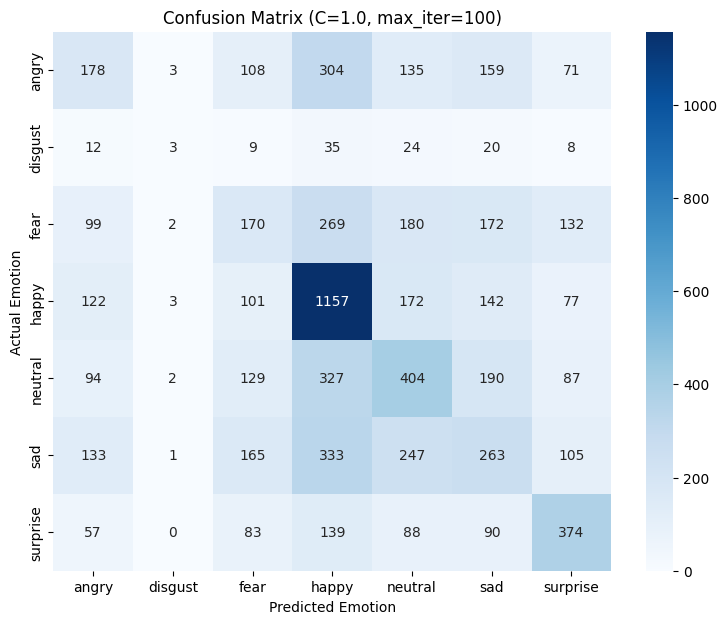


Running Logistic Regression: C=0.1, max_iter=100


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


max_iter reached after 285 seconds
Training time: 285.94 seconds
Train Accuracy: 0.45553659131282875
Test Accuracy: 0.355391473948175

Test Classification Report:
              precision    recall  f1-score   support

       angry       0.26      0.19      0.22       958
     disgust       0.21      0.03      0.05       111
        fear       0.22      0.17      0.19      1024
       happy       0.45      0.65      0.53      1774
     neutral       0.32      0.33      0.33      1233
         sad       0.25      0.21      0.23      1247
    surprise       0.44      0.45      0.44       831

    accuracy                           0.36      7178
   macro avg       0.31      0.29      0.28      7178
weighted avg       0.33      0.36      0.34      7178



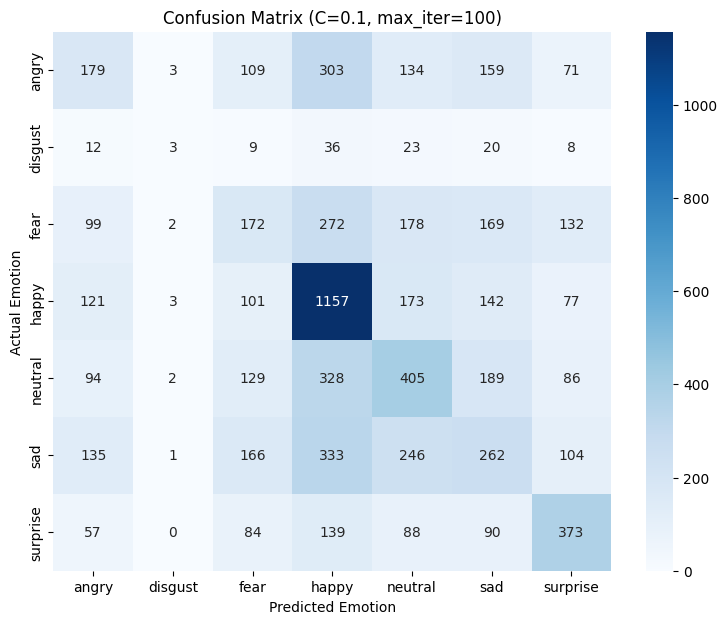


Running Logistic Regression: C=10.0, max_iter=100


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


max_iter reached after 287 seconds
Training time: 286.47 seconds
Train Accuracy: 0.4557804172907451
Test Accuracy: 0.35525215937587074

Test Classification Report:
              precision    recall  f1-score   support

       angry       0.26      0.19      0.22       958
     disgust       0.21      0.03      0.05       111
        fear       0.22      0.17      0.19      1024
       happy       0.45      0.65      0.53      1774
     neutral       0.32      0.33      0.33      1233
         sad       0.25      0.21      0.23      1247
    surprise       0.44      0.45      0.44       831

    accuracy                           0.36      7178
   macro avg       0.31      0.29      0.28      7178
weighted avg       0.33      0.36      0.34      7178



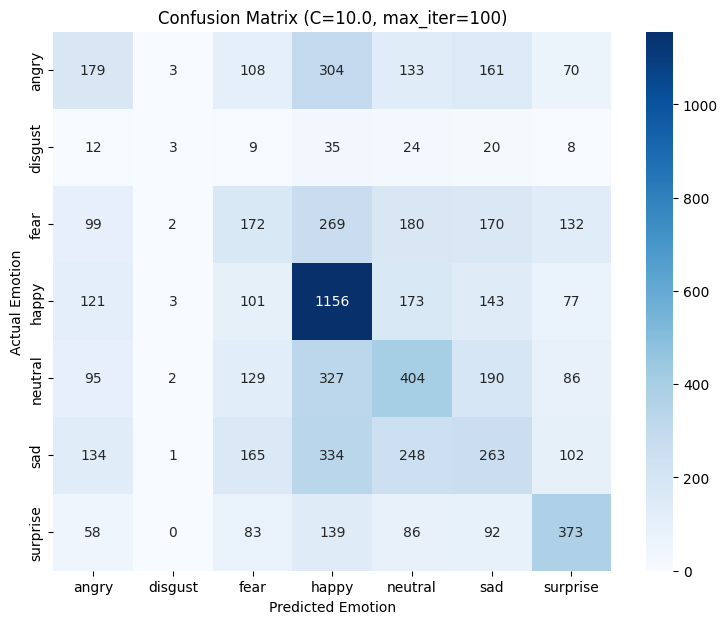

In [ ]:
results = []

results.append(run_logistic_experiment(C_value=1.0, max_iter_value=100))
results.append(run_logistic_experiment(C_value=0.1, max_iter_value=100))
results.append(run_logistic_experiment(C_value=10.0, max_iter_value=100))

In [ ]:
import pandas as pd

results_df = pd.DataFrame([
    {
        "C": r["C"],
        "max_iter": r["max_iter"],
        "train_accuracy": r["train_accuracy"],
        "test_accuracy": r["test_accuracy"],
        "training_time_sec": round(r["training_time"], 2)
    }
    for r in results
])

results_df

,C,max_iter,train_accuracy,test_accuracy,training_time_sec
0,1.0,100,0.455537,0.355113,290.41
1,0.1,100,0.455537,0.355391,285.94
2,10.0,100,0.455780,0.355252,286.47



Running Logistic Regression: C=0.1, max_iter=50


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


max_iter reached after 155 seconds
Training time: 156.16 seconds
Train Accuracy: 0.4390609216621965
Test Accuracy: 0.36221788799108384

Test Classification Report:
              precision    recall  f1-score   support

       angry       0.26      0.17      0.21       958
     disgust       0.30      0.03      0.05       111
        fear       0.24      0.17      0.20      1024
       happy       0.45      0.67      0.54      1774
     neutral       0.33      0.34      0.34      1233
         sad       0.26      0.21      0.23      1247
    surprise       0.45      0.46      0.45       831

    accuracy                           0.36      7178
   macro avg       0.33      0.29      0.29      7178
weighted avg       0.34      0.36      0.34      7178



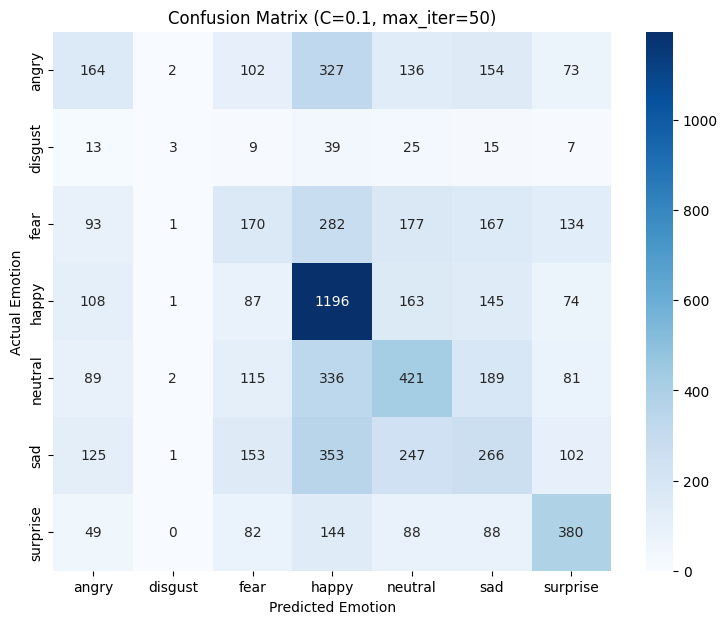


Running Logistic Regression: C=1.0, max_iter=50


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


max_iter reached after 146 seconds
Training time: 147.08 seconds
Train Accuracy: 0.4391305862273155
Test Accuracy: 0.3626358317079967

Test Classification Report:
              precision    recall  f1-score   support

       angry       0.26      0.17      0.21       958
     disgust       0.27      0.03      0.05       111
        fear       0.23      0.16      0.19      1024
       happy       0.45      0.67      0.54      1774
     neutral       0.34      0.34      0.34      1233
         sad       0.26      0.21      0.23      1247
    surprise       0.45      0.46      0.45       831

    accuracy                           0.36      7178
   macro avg       0.32      0.29      0.29      7178
weighted avg       0.34      0.36      0.34      7178



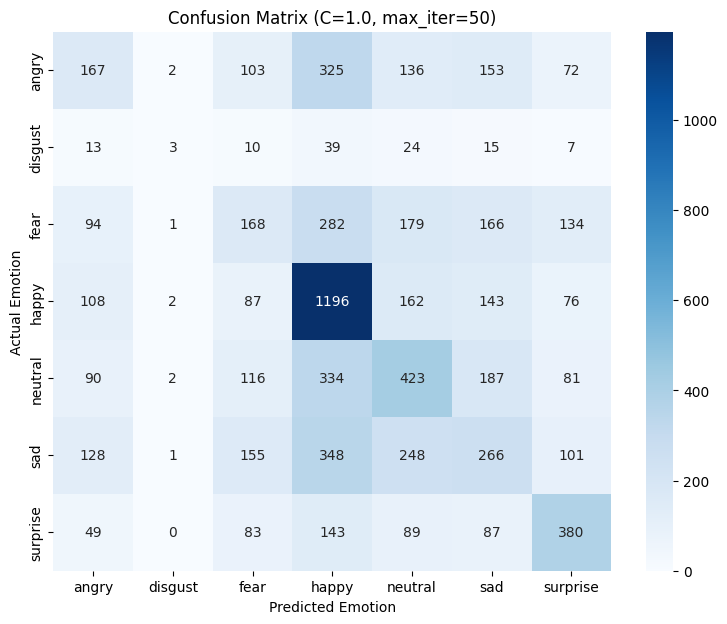


Running Logistic Regression: C=10.0, max_iter=50


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


max_iter reached after 145 seconds
Training time: 145.47 seconds
Train Accuracy: 0.43930474764011285
Test Accuracy: 0.3631930899972137

Test Classification Report:
              precision    recall  f1-score   support

       angry       0.26      0.17      0.21       958
     disgust       0.30      0.03      0.05       111
        fear       0.23      0.17      0.19      1024
       happy       0.45      0.68      0.54      1774
     neutral       0.34      0.34      0.34      1233
         sad       0.26      0.21      0.24      1247
    surprise       0.45      0.46      0.45       831

    accuracy                           0.36      7178
   macro avg       0.33      0.29      0.29      7178
weighted avg       0.34      0.36      0.34      7178



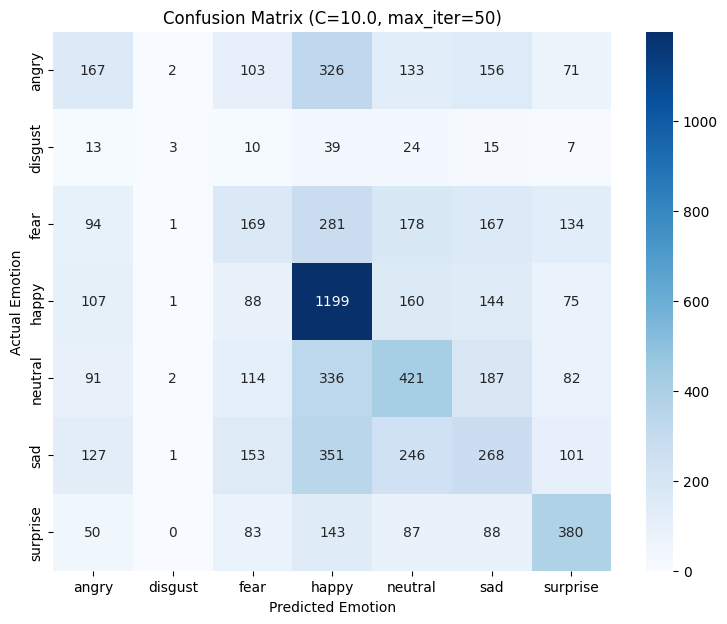

In [ ]:
results = []

# max_iter = 50
results.append(run_logistic_experiment(C_value=0.1, max_iter_value=50))

results.append(run_logistic_experiment(C_value=1.0, max_iter_value=50))

results.append(run_logistic_experiment(C_value=10.0, max_iter_value=50))



In [ ]:
import pandas as pd

results_df = pd.DataFrame([
    {
        "C": r["C"],
        "max_iter": r["max_iter"],
        "train_accuracy": r["train_accuracy"],
        "test_accuracy": r["test_accuracy"],
        "training_time_sec": round(r["training_time"], 2)
    }
    for r in results
])

results_df

,C,max_iter,train_accuracy,test_accuracy,training_time_sec
0,0.1,50,0.439061,0.362218,156.16
1,1.0,50,0.439131,0.362636,147.08
2,10.0,50,0.439305,0.363193,145.47



Running Logistic Regression: C=0.1, max_iter=150


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


max_iter reached after 758 seconds
max_iter reached after 746 seconds
Training time: 747.91 seconds
Train Accuracy: 0.4630255320631161
Test Accuracy: 0.3502368347729172

Test Classification Report:
              precision    recall  f1-score   support

       angry       0.25      0.19      0.22       958
     disgust       0.17      0.04      0.06       111
        fear       0.22      0.17      0.19      1024
       happy       0.45      0.64      0.53      1774
     neutral       0.32      0.31      0.32      1233
         sad       0.25      0.21      0.23      1247
    surprise       0.43      0.45      0.44       831

    accuracy                           0.35      7178
   macro avg       0.30      0.29      0.28      7178
weighted avg       0.33      0.35      0.33      7178



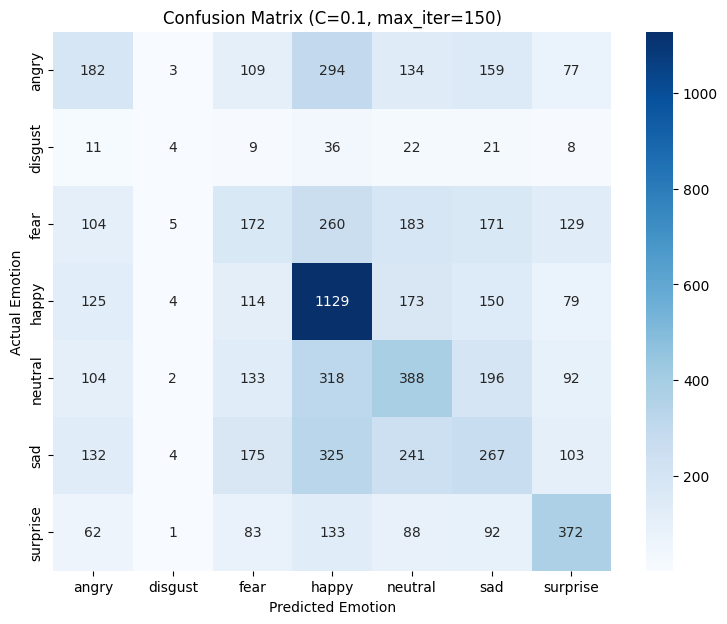


Running Logistic Regression: C=1.0, max_iter=150


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


max_iter reached after 423 seconds
Training time: 423.34 seconds
Train Accuracy: 0.46292103521543765
Test Accuracy: 0.3499582056283087

Test Classification Report:
              precision    recall  f1-score   support

       angry       0.25      0.19      0.22       958
     disgust       0.17      0.04      0.06       111
        fear       0.21      0.17      0.19      1024
       happy       0.45      0.64      0.53      1774
     neutral       0.32      0.31      0.31      1233
         sad       0.25      0.21      0.23      1247
    surprise       0.43      0.45      0.44       831

    accuracy                           0.35      7178
   macro avg       0.30      0.29      0.28      7178
weighted avg       0.33      0.35      0.33      7178



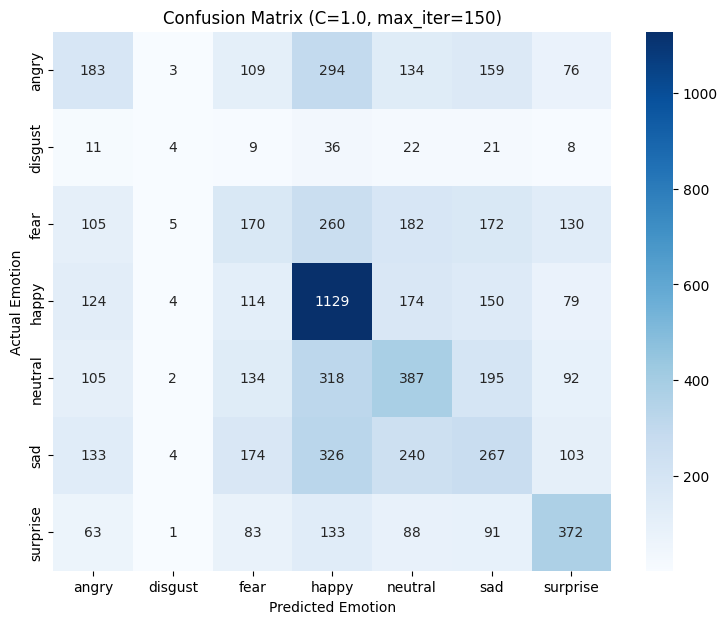


Running Logistic Regression: C=10.0, max_iter=150


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


max_iter reached after 417 seconds
Training time: 417.11 seconds
Train Accuracy: 0.4631300289107945
Test Accuracy: 0.34981889105600444

Test Classification Report:
              precision    recall  f1-score   support

       angry       0.25      0.19      0.22       958
     disgust       0.18      0.04      0.06       111
        fear       0.22      0.17      0.19      1024
       happy       0.45      0.64      0.53      1774
     neutral       0.32      0.31      0.31      1233
         sad       0.25      0.21      0.23      1247
    surprise       0.43      0.45      0.44       831

    accuracy                           0.35      7178
   macro avg       0.30      0.29      0.28      7178
weighted avg       0.33      0.35      0.33      7178



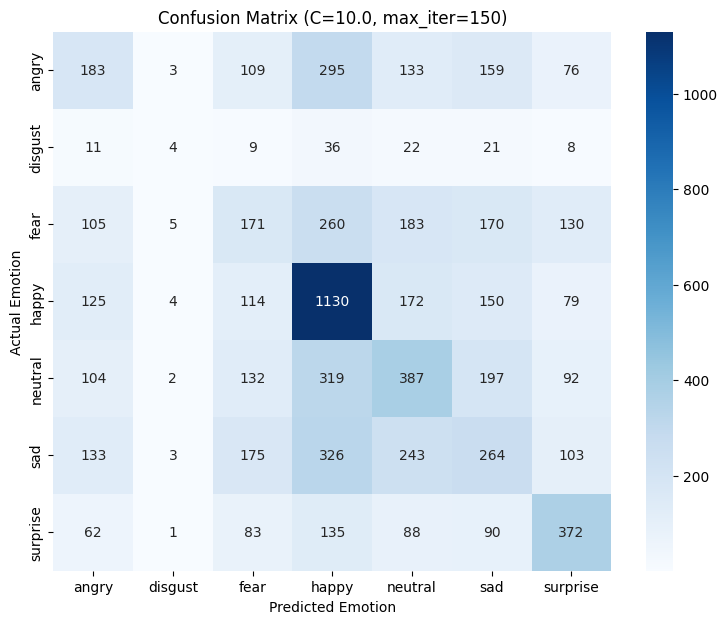

In [ ]:
# max_iter = 150
results.append(run_logistic_experiment(C_value=0.1, max_iter_value=150))

results.append(run_logistic_experiment(C_value=1.0, max_iter_value=150))

results.append(run_logistic_experiment(C_value=10.0, max_iter_value=150))

In [ ]:
import pandas as pd

results_df = pd.DataFrame([
    {
        "C": r["C"],
        "max_iter": r["max_iter"],
        "train_accuracy": r["train_accuracy"],
        "test_accuracy": r["test_accuracy"],
        "training_time_sec": round(r["training_time"], 2)
    }
    for r in results
])

results_df
results_df

,C,max_iter,train_accuracy,test_accuracy,training_time_sec
0,0.1,50,0.439061,0.362218,156.16
1,1.0,50,0.439131,0.362636,147.08
2,10.0,50,0.439305,0.363193,145.47
3,0.1,150,0.463026,0.350237,747.91
4,1.0,150,0.462921,0.349958,423.34
5,10.0,150,0.463130,0.349819,417.11
